In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [6]:
df = pd.read_csv('Steel_industry_data.csv')

In [7]:
df.head()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  str    
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2(tCO2)                             35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  str    
 9   Day_of_week                           35040 non-null  str    
 10  Load_Type                             35040 non-null  str    
dtypes: float64(6), int64(1), s

In [9]:
df.isnull().sum()

date                                    0
Usage_kWh                               0
Lagging_Current_Reactive.Power_kVarh    0
Leading_Current_Reactive_Power_kVarh    0
CO2(tCO2)                               0
Lagging_Current_Power_Factor            0
Leading_Current_Power_Factor            0
NSM                                     0
WeekStatus                              0
Day_of_week                             0
Load_Type                               0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

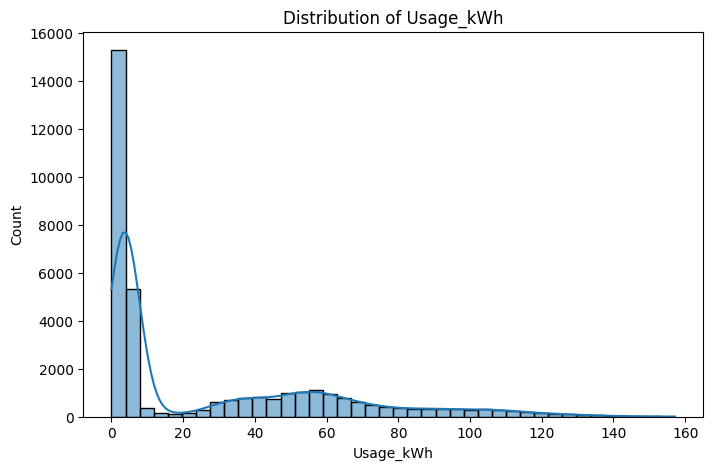

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(df["Usage_kWh"], bins=40, kde=True)

plt.title("Distribution of Usage_kWh")

plt.show()

In [12]:
from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --------------------------------------------
# Define Target
# --------------------------------------------

target = "Usage_kWh"

# --------------------------------------------
# Features and Target
# --------------------------------------------

X = df.drop(columns=[target])

y = df[target]

# --------------------------------------------
# Drop Date Column
# --------------------------------------------

X = X.drop(columns=["date"])

# --------------------------------------------
# Identify Numerical & Categorical Columns
# --------------------------------------------

numeric_features = X.select_dtypes(include=np.number).columns

categorical_features = X.select_dtypes(include="object").columns

print("Numerical Features")
print(numeric_features)

print("\nCategorical Features")
print(categorical_features)

# --------------------------------------------
# Numerical Pipeline
# --------------------------------------------

numeric_pipeline = Pipeline(

    steps=[

        ("imputer", SimpleImputer(strategy="median")),

        ("scaler", StandardScaler())

    ]

)

# --------------------------------------------
# Categorical Pipeline
# --------------------------------------------

categorical_pipeline = Pipeline(

    steps=[

        ("imputer", SimpleImputer(strategy="most_frequent")),

        ("encoder", OneHotEncoder(handle_unknown="ignore"))

    ]

)

# --------------------------------------------
# Column Transformer
# --------------------------------------------

preprocessor = ColumnTransformer(

    transformers=[

        ("num", numeric_pipeline, numeric_features),

        ("cat", categorical_pipeline, categorical_features)

    ]

)


Numerical Features
Index(['Lagging_Current_Reactive.Power_kVarh',
       'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)',
       'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM'],
      dtype='str')

Categorical Features
Index(['WeekStatus', 'Day_of_week', 'Load_Type'], dtype='str')


C:\Users\ss\AppData\Local\Temp\ipykernel_30772\1057826969.py:51: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include="object").columns


In [13]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42

)


In [17]:
model = Pipeline(

    steps=[

        ("preprocessor", preprocessor),

        ("regressor",

            RandomForestRegressor(

                n_estimators=300,

                random_state=42,

                n_jobs=-1

            )

        )

    ]

)


In [18]:
model.fit(

    X_train,

    y_train

)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [19]:
predictions = model.predict(

    X_test

)

# --------------------------------------------
# Evaluation
# --------------------------------------------

mae = mean_absolute_error(

    y_test,

    predictions

)

rmse = np.sqrt(

    mean_squared_error(

        y_test,

        predictions

    )

)

r2 = r2_score(

    y_test,

    predictions

)

print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.4f}")

MAE  : 0.336
RMSE : 1.057
R²   : 0.9990


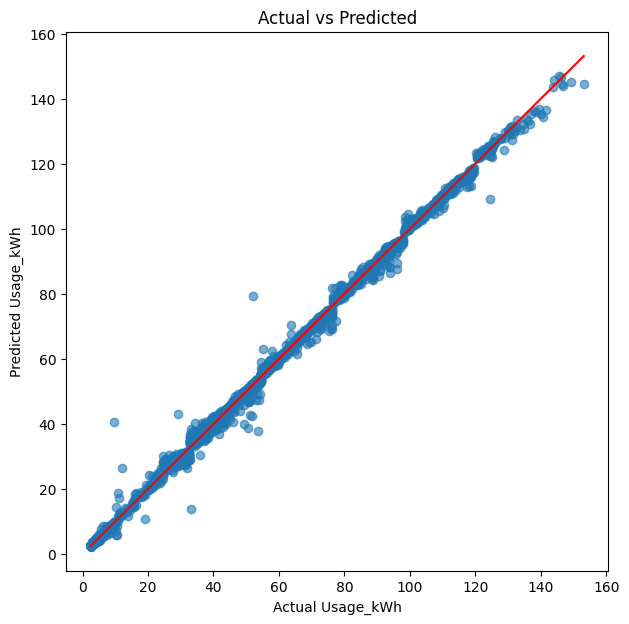

In [20]:
plt.figure(figsize=(7,7))

plt.scatter(

    y_test,

    predictions,

    alpha=0.6

)

plt.plot(

    [y_test.min(), y_test.max()],

    [y_test.min(), y_test.max()],

    color="red"

)

plt.xlabel("Actual Usage_kWh")

plt.ylabel("Predicted Usage_kWh")

plt.title("Actual vs Predicted")

plt.show()

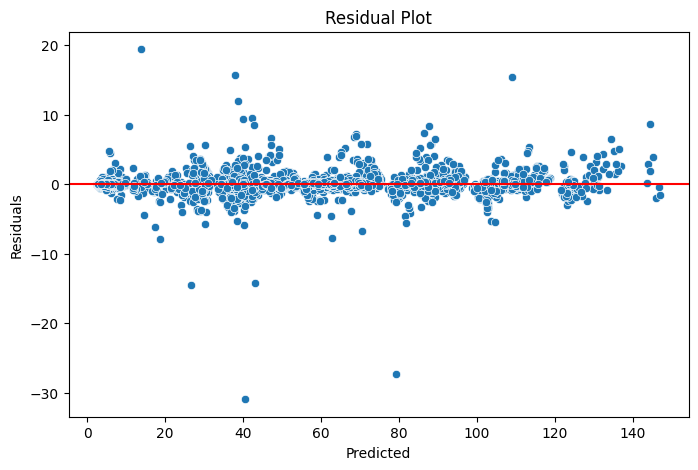

In [21]:
residuals = y_test - predictions

plt.figure(figsize=(8,5))

sns.scatterplot(

    x=predictions,

    y=residuals

)

plt.axhline(

    y=0,

    color="red"

)

plt.xlabel("Predicted")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()


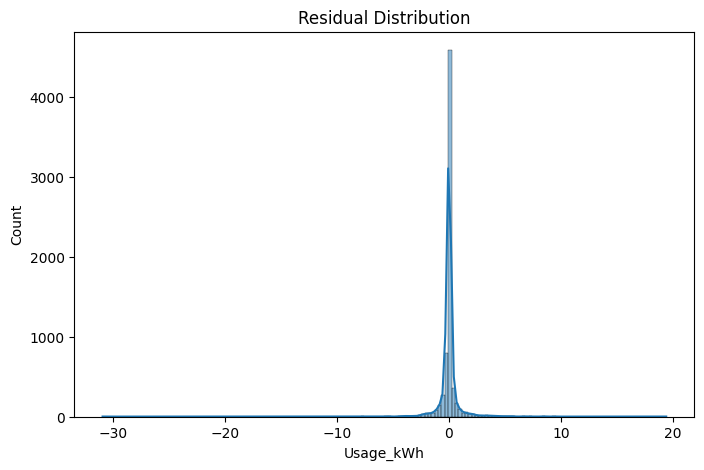

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(

    residuals,

    kde=True

)

plt.title("Residual Distribution")

plt.show()


In [23]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

importance = model.named_steps["regressor"].feature_importances_

importance_df = pd.DataFrame(

    {

        "Feature": feature_names,

        "Importance": importance

    }

)

importance_df = importance_df.sort_values(

    by="Importance",

    ascending=False

)

print(importance_df.head(20))


                                      Feature  Importance
2                              num__CO2(tCO2)    0.975658
0   num__Lagging_Current_Reactive.Power_kVarh    0.015640
3           num__Lagging_Current_Power_Factor    0.005103
4           num__Leading_Current_Power_Factor    0.001323
5                                    num__NSM    0.001254
1   num__Leading_Current_Reactive_Power_kVarh    0.000427
15                  cat__Load_Type_Light_Load    0.000176
7                     cat__WeekStatus_Weekend    0.000089
6                     cat__WeekStatus_Weekday    0.000079
13                   cat__Day_of_week_Tuesday    0.000074
16                cat__Load_Type_Maximum_Load    0.000032
17                 cat__Load_Type_Medium_Load    0.000028
12                  cat__Day_of_week_Thursday    0.000025
14                 cat__Day_of_week_Wednesday    0.000023
9                     cat__Day_of_week_Monday    0.000023
8                     cat__Day_of_week_Friday    0.000020
10            

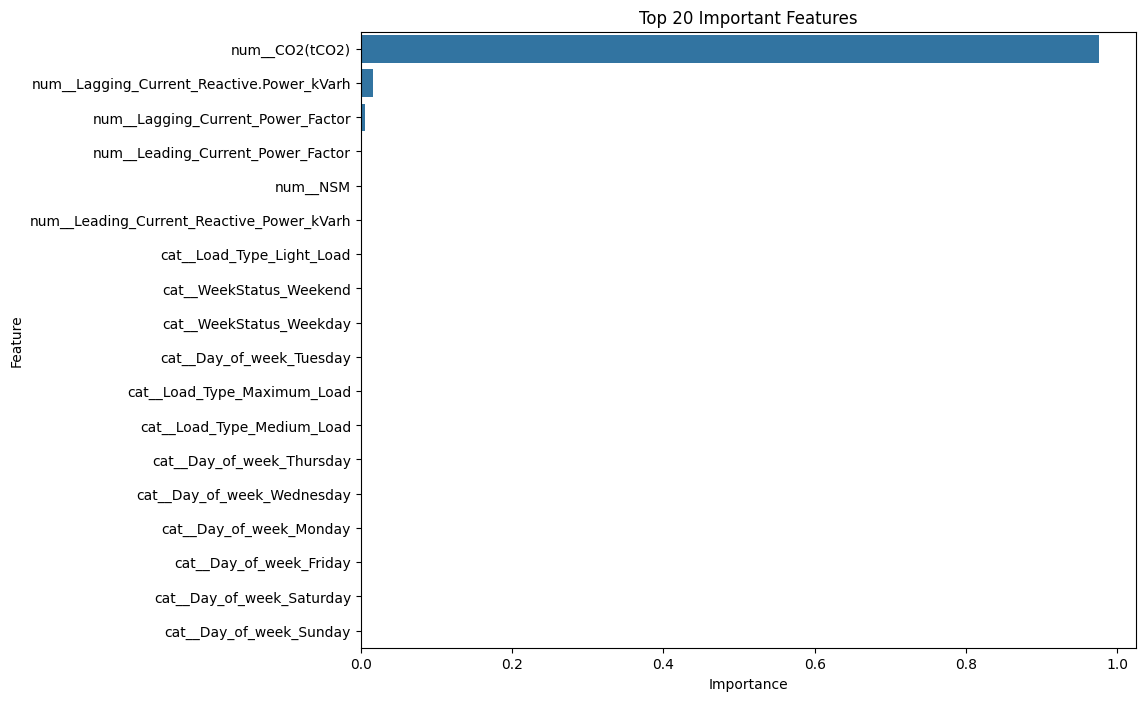

In [24]:
plt.figure(figsize=(10,8))

sns.barplot(

    data=importance_df.head(20),

    x="Importance",

    y="Feature"

)

plt.title("Top 20 Important Features")

plt.show()